# Control and Learning — A Synthesis of Connections and Limits

*Introduction to Control and Machine Learning · Synthesis · Notebook 17*

> **Central question.** *Which mathematical connections between controlling systems and training models are exact, which are analogies, which hold only under hypotheses, and where do they stop?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 55–70 min · DEEPER LOOK and RESEARCH WINDOW ≈ 20 min more |
| **Execution time** | a few seconds |
| **Exercises** | 4 synthesis exercises, ≈ 60–120 min |
| **Prerequisites** | the CORE of notebooks 00–16; in particular [03](03_observability_duality_adjoints.ipynb), [07](07_adjoints_density_heat_control.ipynb), [08](08_long_time_control_turnpike.ipynb), [10](10_training_gd_sgd.ipynb), [11](11_optimization_algorithms_ml.ipynb), [13](13_resnets_neural_odes.ipynb), [14](14_classification_as_simultaneous_control.ipynb), [16](16_neural_transport.ipynb) |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 132, 247–249, 329–332, 354–360, 363, 384 (see the Source map at the end) |
| **Notation** | as in `notation.md`; no new symbols. E1 is the harmonic oscillator $A=\begin{pmatrix}0&1\\-1&0\end{pmatrix}$, $B=\begin{pmatrix}0\\1\end{pmatrix}$, state $x=(x_1,x_2)$ |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

> **First pass through this notebook.**
> *Essential:* the CORE sections §§1–4 (three threads, with the discrete adjoint derived once; the dictionary with its scope; E1 as four different problems; capacity, optimization and generalization), Figure 1, Exercise 1.
> *Deeper study:* the DEEPER LOOK §6 (a full numerical gradient check) and Exercises 2–3.
> *Research-oriented:* the RESEARCH WINDOW §7 and the `ADVANCED` Exercise 4.

**Learning objectives.** After this notebook you should be able to

1. trace the three threads of the course (adjoints and gradients, gradient dynamics, controllability and representation) to the notebooks where each step is proved or measured;
2. derive the discrete adjoint recursion and the parameter gradient of a residual network from a Lagrangian, and state when it is exact;
3. classify a control ↔ ML connection as an identity in a specified model, a mathematical analogy, or a result under hypotheses, and state its scope;
4. tell apart four problems posed on the same oscillator: steering, stabilization, long-horizon optimal control and learning a field;
5. separate questions of capacity, optimization and generalization, and say what each one does and does not guarantee.

## Where are we?
`CORE`

The slides close Part I by stating that *controllability and observability are equivalent notions (Wiener's cybernetics)*, that both hold *if and only if the Kalman rank condition is fulfilled*, that controls *may be obtained as minimizers of suitable quadratic functionals over the space of solutions of the adjoint system*, and that *controllable systems are stabilizable by means of closed loop or feedback controls* (p. 132). They announce the goal of the fusion as *opening the black box of machine learning with control-theoretical tools*: explainability, generalization, robustness, complexity, computational cost (p. 329), with *lots to do* (p. 330).

This notebook adds no new theory. It says what kind of statement each connection is and where it ends, pointing to the notebook where it was proved, transcribed or measured. The figure re-runs existing procedures and selects nothing; all other numbers are quoted from earlier notebooks.

## 1. Three threads, and where each one stops
`CORE`

### Thread 1: adjoints and gradients

**Duality, stated precisely.** For a finite-dimensional linear time-invariant system $x'=Ax+Bu$, the pair $(A,B)$ is controllable (on any $[0,T]$, $T>0$) **if and only if** the pair $(A^\top,B^\top)$ is observable. Both are equivalent to the Kalman rank condition: the Kalman matrix of $(A,B)$ is, up to transposition, the observability matrix of $(A^\top,B^\top)$. This is the precise content of p. 132's "equivalent notions", and the basis of HUM in notebook 03: the controls are built from solutions of the adjoint system $-\varphi'=A^\top\varphi$, and the functional is coercive exactly when the adjoint is observable. In infinite dimension, as for the heat equation of notebook 07, exact, null and approximate controllability correspond to *different* observability (or unique-continuation) properties of the adjoint. There is no single "equivalence" there.

**The adjoint method, with its hypotheses** (07). Let a scalar cost $J(u)=j(x(u),u)$ be constrained by a state equation $e(x,u)=0$ that has a unique solution $x(u)$, with $e$ and $j$ continuously differentiable and $\partial_xe$ invertible (so that $u\mapsto x(u)$ is differentiable, by the implicit function theorem). Then $\nabla J$ is obtained from **one state solve and one adjoint solve**, whatever the number of controls. That is the computational *structure* for one scalar objective. It is not a constant cost: each solve costs as much as the problem size dictates, and $m$ scalar outputs need $m$ adjoint solves.

**The discrete adjoint of a residual network, derived once** *(the computation of notebook 13, §4, for one sample)*. Take the explicit scheme $x_{k+1}=x_k+hf(x_k,\theta_k)$, $k=0,\dots,K-1$, $x_0$ given, and the training objective
$$
J(\Theta)=\Phi(x_K)+h\sum_{k=0}^{K-1}\ell(x_k)+\alpha h\sum_{k=0}^{K-1}|\theta_k|^2 ,
$$
with $f$, $\Phi$, $\ell$ continuously differentiable. The scheme is explicit, so the states are well defined for every $\Theta$. Adjoin each step with a multiplier $p_{k+1}$:
$$
\mathscr L=J(\Theta)-\sum_{k=0}^{K-1}p_{k+1}\cdot\big(x_{k+1}-x_k-hf(x_k,\theta_k)\big).
$$
On trajectories of the scheme, $\mathscr L=J$ for any multipliers. Choosing them so that $\partial\mathscr L/\partial x_k=0$ for $k=K,\dots,1$ gives the **discrete adjoint recursion**
$$
p_K=\nabla\Phi(x_K),\qquad p_k=\big(I+hD_xf(x_k,\theta_k)\big)^{\!\top}p_{k+1}+h\nabla\ell(x_k),
$$
and what remains is the **parameter gradient**
$$
\nabla_{\theta_k}J=h\,D_\theta f(x_k,\theta_k)^{\top}p_{k+1}+2\alpha h\,\theta_k .
$$
This is backpropagation. With $N$ samples, the data terms are averaged, $p_K=\nabla\Phi_n/N$ per sample, and the regularization is counted once (13).

*Where it stops.*
- **The identity is exact for one specified discrete cost and scheme.** Whether discretizing the continuous adjoint system gives the same vector depends on the discretization. A *compatible* discretization reproduces the recursion above exactly. The particular one implemented in `src/node_utils.py` (`continuous_adjoint_gradient`) evaluates the Jacobian at $x_{k+1}$ instead of $x_k$ and uses $p_k$ instead of $p_{k+1}$ in the gradient. At a fixed horizon, with piecewise-constant controls whose pieces are identified across nested meshes, its gradient is *observed* to differ from the discrete one by an amount of order $h$ in relative Euclidean norm, in the examples of 13 §8 and DEEPER LOOK §6. A theoretical bound would naturally be an absolute one, of order $h$ for smooth fields and this parametrization. A relative statement also needs the reference gradient to stay away from zero: near a vanishing gradient the relative error can be undefined or lose this order.
- **"One forward and one backward pass" fixes the number of passes, not the work.** The work grows with the number of samples, layers, width and dimension, and the forward states must be stored or recomputed.

### Thread 2: gradient dynamics and training
- **06:** gradient descent is the explicit Euler scheme of the gradient flow, stable only for small enough steps.
- **10:** stochastic gradient descent replaces the gradient by a sampled one, which is unbiased conditionally on the current iterate when the indices are drawn independently of the past, as with sampling with replacement (10). With epoch-wise reshuffling (without replacement) this holds for the first step of each epoch, not for later steps conditionally on the earlier ones. With a constant step and nonzero gradient noise at the optimum, the iterates were seen to settle in a neighbourhood whose size depends on the step and the batch. An upper bound on that residual does not prove a positive floor in general.
- **11:** momentum and adaptive methods add memory and coordinate-wise scaling.

The heavy ball is a discretized damped oscillator *for any differentiable $F$*: the scheme
$$
\frac{w_{k+1}-2w_k+w_{k-1}}{h^2}+\nu\,\frac{w_k-w_{k-1}}{h}+\nabla F(w_k)=0
$$
is exactly the heavy-ball update with $\eta=h^2$ and $\beta=1-\nu h$ (11). What requires a **quadratic** $F$ is the next step: the reduction to independent linear oscillator modes, and the spectral tuning results of 11, such as the critical momentum and its rate.

*Where it stops.* Continuous time, discrete steps, sampling noise and stability conditions are four different layers of the same picture. A decreasing training loss is a statement about optimization, never by itself about generalization (09).

### Thread 3: controllability and representation
- **02:** Kalman's rank condition decides controllability of a *linear* system.
- **12:** one hidden layer represents finitely many distinct data points exactly.
- **13:** a ResNet is the Euler scheme of a controlled ODE.
- **14:** a ReLU neural ODE steers finitely many points into their label regions (simultaneous control).
- **15:** attention makes the points interact.
- **16:** a flow transports measures, and the same fields can learn a vector field from trajectories.

*Where it stops:*
- Kalman says nothing about controllability of a nonlinear network.
- Interpolating or classifying a finite set exactly does not guarantee predicting well (12, 14).
- A ResNet trained with large steps need not be an injective flow (13).
- Hardmax leadership can appear after layer $0$, and the clustering theorem does not describe practical transformers with softmax and feed-forward blocks (15).
- Matching atoms exactly does not transport the law they were drawn from (16).
- A field that depends affinely on a relaxed control (a measure) does not make the dynamic problem convex (14, 12).

## 2. The dictionary, with its scope
`CORE`

The table classifies each connection in one of three ways:
- **DIRECT CONNECTION**: an *identity in a specified model*, exact once the model is fixed;
- **MATHEMATICAL ANALOGY**: the same structure, different objects, no theorem transferred;
- **RESULT UNDER HYPOTHESES**: a theorem, transcribed from the slides or proved in the course, valid only under the hypotheses listed.

None of these is a universal equivalence between control and machine learning.

| Control | Machine learning | Kind | Scope and hypotheses | Where |
|---|---|---|---|---|
| state $x_k$, dynamics $x_{k+1}=x_k+hf(x_k,\theta_k)$ | features through the layers of a ResNet | **DIRECT CONNECTION** | the ResNet *is* this Euler scheme; it approximates the flow map only at a fixed horizon, with small steps and regular controls | 13 |
| adjoint state $p_k$ | backpropagated sensitivity | **DIRECT CONNECTION** | exact gradient of the specified discrete cost ($C^1$ data); a discretized continuous adjoint agrees only if the discretization is compatible (13's natural choice: observed about $O(h)$ apart in its examples) | 07, 13 |
| control cost $\alpha\int\|\theta\|^2$ | $L^2$ penalty on parameters | **DIRECT CONNECTION** | as a term of the objective; decoupled weight decay (AdamW) is a different update | 13 |
| gradient flow and its Euler scheme | gradient descent on a loss | **DIRECT CONNECTION** | step condition for stability; SGD adds sampling noise | 06, 10 |
| damped oscillator $w''+\nu w'+\nabla F(w)=0$ | heavy-ball momentum | **DIRECT CONNECTION** (scheme) / **MATHEMATICAL ANALOGY** (behaviour) | the discretization identity holds for differentiable $F$; mode decomposition and spectral tuning need a quadratic $F$ | 05, 11 |
| controllability of $(A,B)$ ⇔ observability of $(A^\top,B^\top)$ | — | **RESULT UNDER HYPOTHESES** | finite-dimensional, linear, time-invariant; different notions in infinite dimension | 02, 03, 07 |
| Kalman controllability | expressivity of networks | **MATHEMATICAL ANALOGY** | Kalman is linear; network results need their own hypotheses | 02, 14 |
| simultaneous control into open sets | exact classification of training points | **RESULT UNDER HYPOTHESES** | ReLU NODE, $d\ge2$, distinct or compatible inputs (p. 338, audited); nothing about new points | 14 |
| turnpike over long horizons | very deep networks | **MATHEMATICAL ANALOGY** | proved in 08 for linear-quadratic problems penalizing state and control, with $(A,B)$ controllable and $(A,C)$ observable: sufficient, not necessary, hypotheses; no universal theorem for trained networks | 08, 13 |
| consensus / interacting particles | hardmax self-attention | **RESULT UNDER HYPOTHESES** | clustering for nonzero distinct tokens, $A$ symmetric positive definite, $V=\alpha I$, pure hardmax; leadership can emerge | 15 |
| transport equation, characteristics | normalizing flows | **RESULT UNDER HYPOTHESES** | $W_1$-approximation for compactly supported absolutely continuous laws (p. 373); atoms are not laws | 16 |
| relaxed controls (measures) | mean-field networks | **RESULT UNDER HYPOTHESES** | static no-gap theorem for shallow networks (p. 348); in dynamics the field is linear in the measure, the flow is not | 12, 14 |

## 3. One oscillator, four different problems
`CORE`

The harmonic oscillator E1 runs through the whole course. Figure 1 shows four problems posed on it. They are **not** four methods competing for one objective: each panel has its own question, horizon and criterion, and two of them use different matrices.

| Panel | System | Initial state, horizon | Control or criterion | Question answered | Where |
|---|---|---|---|---|---|
| (a) | E1: $x'=Ax+Bu$ | $x^0=(1,0)$, $T=5$ | the minimal-$L^2$ steering control (Gramian) | can E1 be steered exactly to $x^1=0$ in time $T$? | 02, 03 |
| (b) | E1 under $u=-kx_2$: $A_k=\begin{pmatrix}0&1\\-1&-k\end{pmatrix}$ | $x^0=(1,0)$, $t\in[0,20]$ | feedback gain $k=0.5,2,8$ | does the closed loop decay, and how fast? | 05 |
| (c) | E1 with cost $\frac12\int_0^T(\|u\|^2+\|x-x^*\|^2)\,dt$ | $x^0=0$, $T=20$, $x^*=(2,7)$ | optimal control (optimality system) | does the optimal trajectory stay near the steady optimum? | 08 |
| (d) | $z'=A_{\rm cl}z$, $A_{\rm cl}=A+B(-1,-3)=\begin{pmatrix}0&1\\-2&-3\end{pmatrix}$ | 3 validation initial conditions of 16, $T=3$ | SA-NODE: outer weights fitted by least squares on fixed random features | can a neural field reproduce this vector field along trajectories? | 16 |

**Panel (d), precisely.** It is E1 under $u=-x_1-3x_2$, not one of the damped oscillators of (b): its $(2,1)$ entry is $-2$ (Exercise 3).
- *What is fitted.* Only the outer weights $W$ of $x'=W\sigma(A_1x+a_2t+b)$ are fitted, by ridge least squares, over **fixed random inner features**. The fit uses **privileged derivative targets**: the true field $A_{\rm cl}z$ at points of the 20 training trajectories.
- *What it is not.* This is not end-to-end training of a neural ODE from trajectory observations. That would adjust all parameters through the flow, typically with adjoint gradients (13), from states alone.
- *Frozen choices.* Notebook 16's choices are reused unchanged: $P=160$, $\lambda=10^{-6}$, the same features. The data come from the shared helper `lab_b_development_data`, which is tested to reproduce 16 exactly and never creates 16's evaluation stream.
- *What the curves are.* They are 16's **validation** trajectories, already used to choose $P$ and $\lambda$: an illustration of the fit, not an independent test.

> **Predict.** (i) Which of the four problems prescribes a terminal state? (ii) Does increasing the feedback gain $k$ always make the closed loop converge faster? (iii) Why can the steady optimum of (c) differ from the tracking target $x^*=(2,7)$? (iv) Does accurate fitting of the validation trajectories in (d) establish that the learned model is stable?

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

from src.control_utils import (harmonic_oscillator, damped_oscillator, gramian_control, simulate, spectral_abscissa,
                               lq_steady_state, lq_optimality_system)
from src.ml_utils import make_streams
from src.transport_utils import (lab_b_development_data, sa_features, fit_outer_weights, sa_node_rollout,
                                 trajectory_error)
from src.plotting_utils import apply_style, COLORS

apply_style()
np.set_printoptions(precision=4, suppress=True)

# Panel (d) re-uses notebook 16's development data (protocol_12_16.md, section 16): root seed 16, streams "data" and
# "features" only, through the tested helper that reproduces 16's draw order. The evaluation stream is not created.
streams, stream_keys = make_streams(16, ["data", "features"])
ic_train, ic_val, A1_all, a2_all, b_all = lab_b_development_data(streams["data"], streams["features"])
print("stream keys:", stream_keys)

stream keys: {'data': (16, 0), 'features': (16, 3)}


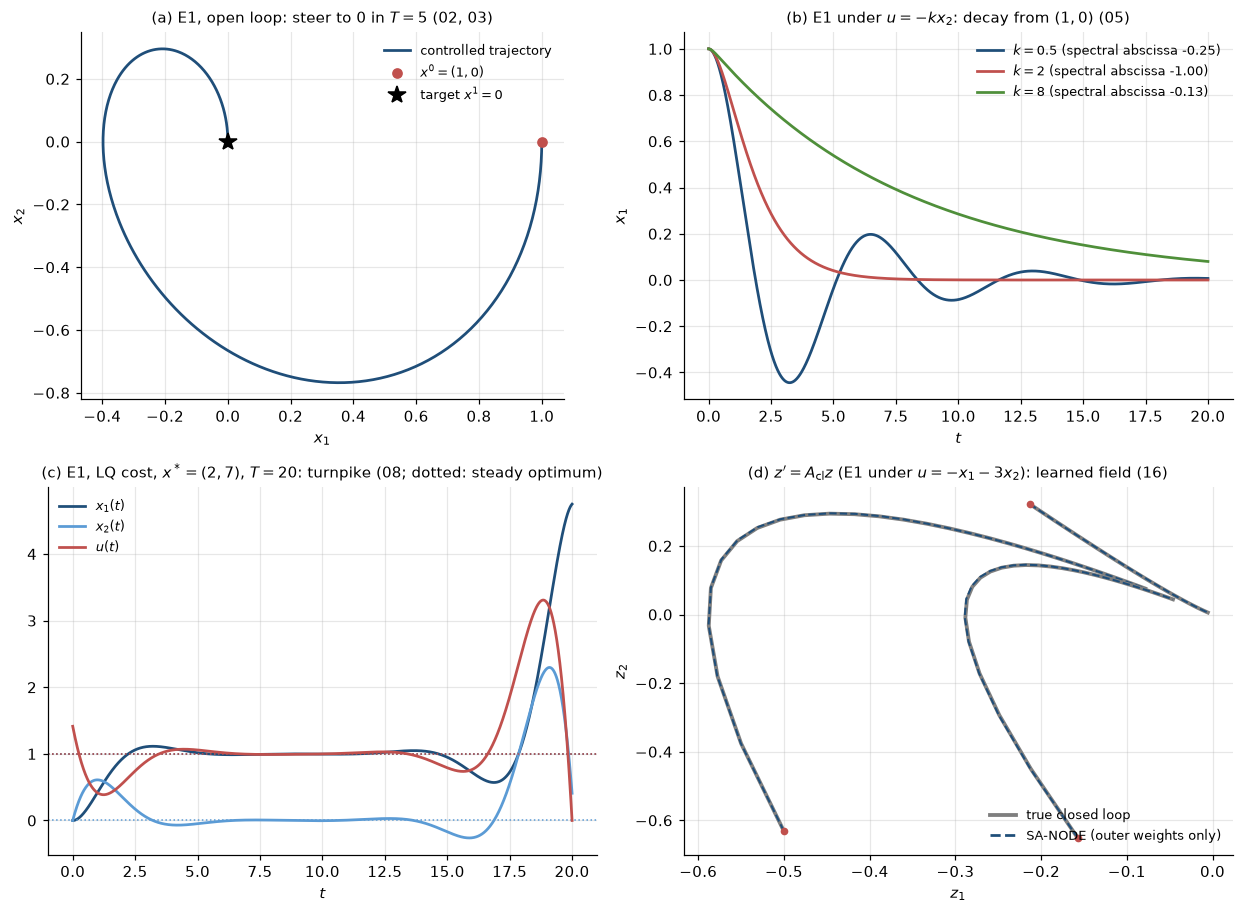

In [2]:
A, B = harmonic_oscillator()
fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.4))

# (a) Steering E1 from (1, 0) to 0 in T = 5 with the minimal-energy control of notebooks 02-03.
T_a, x0_a, x1_a = 5.0, np.array([1.0, 0.0]), np.zeros(2)
t_a = np.linspace(0, T_a, 501)
u_a = gramian_control(A, B, T_a, x0_a, x1_a)
x_a = simulate(A, B, u_a, x0_a, T_a, t_a)
ax = axes[0, 0]
ax.plot(x_a[:, 0], x_a[:, 1], color=COLORS["state"], label="controlled trajectory")
ax.plot(*x0_a, "o", color=COLORS["control"], label="$x^0=(1,0)$"); ax.plot(*x1_a, "*", ms=12, color="black", label="target $x^1=0$")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.legend(fontsize=8.5); ax.set_aspect("equal")
ax.set_title("(a) E1, open loop: steer to 0 in $T=5$ (02, 03)", fontsize=10)

# (b) Feedback u = -k x2 (notebook 05): three gains, same initial state.
t_b = np.linspace(0, 20, 2001)
ax = axes[0, 1]
for k, col in zip((0.5, 2.0, 8.0), (COLORS["state"], COLORS["control"], COLORS["adjoint"])):
    A_k, _ = damped_oscillator(k)
    x_b = simulate(A_k, B, lambda s: np.zeros(1), [1.0, 0.0], 20.0, t_b)
    ax.plot(t_b, x_b[:, 0], color=col, label=f"$k={k:g}$ (spectral abscissa {spectral_abscissa(A_k):.2f})")
ax.set_xlabel("$t$"); ax.set_ylabel("$x_1$"); ax.legend(fontsize=8.5)
ax.set_title("(b) E1 under $u=-kx_2$: decay from $(1,0)$ (05)", fontsize=10)

# (c) Turnpike (notebook 08): LQ cost with target x* = (2, 7), x0 = 0, T = 20.
C, x_star = np.eye(2), np.array([2.0, 7.0])
x_bar, u_bar, _ = lq_steady_state(A, B, C, x_star)
T_c = 20.0
t_c = np.linspace(0, T_c, 4001)
x_c, _, u_c = lq_optimality_system(A, B, C, x_star, np.zeros(2), T_c, t_c)
ax = axes[1, 0]
for i, col in ((0, COLORS["state"]), (1, COLORS["state2"])):
    ax.plot(t_c, x_c[:, i], color=col, label=f"$x_{i + 1}(t)$")
    ax.axhline(x_bar[i], color=col, ls=":", lw=1)
ax.plot(t_c, u_c[:, 0], color=COLORS["control"], label="$u(t)$"); ax.axhline(u_bar[0], color=COLORS["control"], ls=":", lw=1)
ax.set_xlabel("$t$"); ax.legend(fontsize=8.5)
ax.set_title(r"(c) E1, LQ cost, $x^*=(2,7)$, $T=20$: turnpike (08; dotted: steady optimum)", fontsize=10)

# (d) The closed loop of p. 380, fitted by an SA-NODE with 16's frozen choices (P = 160, lambda = 1e-6).
A_cl = A + B @ np.array([[-1.0, -3.0]])
t_d = np.linspace(0.0, 3.0, 31)
exact = lambda z0: np.array([expm(A_cl * t) @ z0 for t in t_d])
Z_train = np.array([exact(z0) for z0 in ic_train])
P, lam = 160, 1e-6
inner = (A1_all[:P], a2_all[:P], b_all[:P])                                # fixed random features: not trained
W = fit_outer_weights(sa_features(Z_train.reshape(-1, 2), np.tile(t_d, len(ic_train)), *inner),
                      Z_train.reshape(-1, 2) @ A_cl.T, lam)                       # privileged targets f(z) = A_cl z
val_errors = np.array([trajectory_error(exact(z0), sa_node_rollout(z0, W, *inner, t_d)) for z0 in ic_val])
ax = axes[1, 1]
for z0 in ic_val[:3]:
    ax.plot(*exact(z0).T, color=COLORS["reference"], lw=2.5)
    ax.plot(*sa_node_rollout(z0, W, *inner, t_d).T, "--", color=COLORS["state"], lw=1.3)
    ax.plot(*z0, "o", color=COLORS["control"], ms=4)
ax.plot([], [], color=COLORS["reference"], lw=2.5, label="true closed loop")
ax.plot([], [], "--", color=COLORS["state"], label="SA-NODE (outer weights only)")
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$"); ax.legend(fontsize=8.5, loc="lower right")
ax.set_title("(d) $z'=A_{\\rm cl}z$ (E1 under $u=-x_1-3x_2$): learned field (16)", fontsize=10)
plt.tight_layout(); plt.show()

**Figure 1.** Four problems on the oscillator E1. (a) Open-loop steering of E1 from $(1,0)$ to $0$ in $T=5$ with the minimal-$L^2$ control. (b) The closed loops $u=-kx_2$ for three gains, first coordinate against time. (c) The optimal trajectory and control for the linear-quadratic cost with target $x^*=(2,7)$ on $[0,20]$, with the steady optimum dotted. (d) The closed loop $z'=A_{\rm cl}z$ ($u=-x_1-3x_2$, a different matrix from (b)) and its SA-NODE model (outer weights fitted over fixed random features, privileged derivative targets, notebook 16's frozen choices) on three validation trajectories.

*Interpretation.* Each panel answers its own question, and the panels are not ranked. The diagnostics are printed by the next cell.

In [3]:
print(f"(a) |x(T) - x1| = {np.linalg.norm(x_a[-1] - x1_a):.1e}")
for k in (0.5, 2.0, 8.0):
    lam_k = np.linalg.eigvals(damped_oscillator(k)[0])
    print(f"(b) k = {k:3.1f}: eigenvalues {np.round(lam_k, 4)}, spectral abscissa {lam_k.real.max():.3f}")
dev_c = np.linalg.norm(x_c - x_bar, axis=1) + np.abs(u_c[:, 0] - u_bar[0])          # |x - x_bar|_2 + |u - u_bar|
print(f"(c) steady optimum x_bar = {x_bar}, u_bar = {u_bar[0]:.3f} (target x* = {x_star});  "
      f"deviation at t = T/2: {dev_c[len(t_c) // 2]:.1e}")
for a in (0.25, 0.3, 0.4):
    window = (t_c >= a * T_c) & (t_c <= (1 - a) * T_c)
    print(f"    max of |x - x_bar| + |u - u_bar| on [{a:.2f} T, {1 - a:.2f} T] = [{a * T_c:4.1f}, {(1 - a) * T_c:4.1f}]: "
          f"{dev_c[window].max():.1e}")
print(f"(d) eigenvalues of A_cl: {np.sort(np.linalg.eigvals(A_cl).real)};  mean trajectory error on the 10 validation "
      f"trajectories {val_errors.mean():.2e} (already used for selection in 16; not an independent test)")

(a) |x(T) - x1| = 9.6e-12
(b) k = 0.5: eigenvalues [-0.25+0.9682j -0.25-0.9682j], spectral abscissa -0.250
(b) k = 2.0: eigenvalues [-1.+0.j -1.-0.j], spectral abscissa -1.000
(b) k = 8.0: eigenvalues [-0.127+0.j -7.873+0.j], spectral abscissa -0.127
(c) steady optimum x_bar = [1. 0.], u_bar = 1.000 (target x* = [2. 7.]);  deviation at t = T/2: 5.9e-03
    max of |x - x_bar| + |u - u_bar| on [0.25 T, 0.75 T] = [ 5.0, 15.0]: 3.9e-01
    max of |x - x_bar| + |u - u_bar| on [0.30 T, 0.70 T] = [ 6.0, 14.0]: 1.1e-01
    max of |x - x_bar| + |u - u_bar| on [0.40 T, 0.60 T] = [ 8.0, 12.0]: 5.2e-02
(d) eigenvalues of A_cl: [-2. -1.];  mean trajectory error on the 10 validation trajectories 3.18e-03 (already used for selection in 16; not an independent test)


*Reading Figure 1 (answers to the predictions).*
- **(i) A terminal state** is prescribed only in (a): the control must bring the state *exactly* to $x^1=0$ at $T=5$, and does so up to the integrator's accuracy. Problem (c) penalizes the distance to $x^*$ along the whole interval but imposes no terminal state. Problem (b) has no horizon at all, and (d) is a fitting problem.
- **(ii) No: a larger gain does not always mean faster convergence.** The spectral abscissa, the largest real part of the eigenvalues, gives the asymptotic exponential rate: $|x(t)|\le C_\varepsilon e^{(\alpha+\varepsilon)t}$ for every $\varepsilon>0$, where $\alpha$ is the abscissa. Here $\alpha=-0.25$, $-1$ and $\approx-0.13$ for $k=0.5,2,8$ (printed): the overdamping paradox of 05.
  - At **critical damping** $k=2$ the eigenvalue $-1$ is double and the matrix is not diagonalizable, so solutions behave like $(c_1+c_2t)e^{-t}$. The rate is $e^{-t}$ with a polynomial prefactor, which is why $\varepsilon>0$ is needed in the bound.
  - The abscissa says nothing about the transient, which can grow before it decays when the matrix is non-normal (Exercise 3).
- **(iii) The steady optimum differs from $x^*$** because $x^*=(2,7)$ is not an equilibrium of E1 with any constant control: an equilibrium needs $x_2=0$ and $x_1=u$. The steady optimum is the best compromise between the state and control costs, $\bar x=(1,0)$, $\bar u=1$ (printed). Over a long horizon the optimal solution stays near it in the interior: the turnpike of 08.
  - The printed deviation $|x-\bar x|_2+|u-\bar u|$ shrinks as the interval moves away from both ends: its maximum is about $0.39$ on $[0.25T,0.75T]$, $0.11$ on $[0.3T,0.7T]$ and $0.05$ on $[0.4T,0.6T]$, and it is $0.006$ at $t=T/2$. This is consistent with deviations that decay exponentially away from both ends.
  - It **illustrates**, for one horizon, the theorem of 08: linear-quadratic cost on state and control, $(A,B)$ controllable, $(A,C)$ observable, here with $C=I$. It does not prove it.
- **(iv) No: accurate trajectory fitting does not establish stability.** The validation errors are small (printed), on initial conditions in $[-1,1]^2$ over $[0,3]$, and on trajectories already used for the choice. The learned field is a ReLU field with time as an input. Nothing shown here bounds its behaviour for larger times or outside the training region, where notebook 16's frozen final evaluation found errors about thirteen times larger. Stability of the learned model would need its own argument, which was not given.

## 4. Capacity, optimization, generalization: three different questions
`CORE`

Three questions recur under different names:
- **Capacity:** can some parameters (controls) achieve the goal on the given data?
- **Optimization:** does the procedure find such parameters?
- **Generalization:** do the parameters found predict well on new data from the same law?

They are related but distinct. Achieving a fit presupposes enough capacity for that fit. Beyond that, **expressive capacity alone does not guarantee that training finds a good model, and a small training loss alone does not guarantee generalization.** The course has examples of each gap; the numbers below are quoted from the frozen protocols of `reports/protocol_12_16.md` and the notebooks.

- **12.** The exact interpolant $P_0$ represents all 36 noisy training points with 36 neurons. The sparse regression chosen on validation data ($\lambda=300$, 10 neurons) had the smaller validation error. On 500 new samples the mean absolute errors were $0.323$ and $0.289$. Exactness and sparsity are statements about the training data; validation decided.
- **13–14.** Both the trained network of 13 and the constructed control of 14 classify the 72 E6 training points perfectly. On 2000 new observations of the declared E6 law, the joint evaluation counted **22 errors against 755**. The constructed control's error rate, $0.378$, is poor in absolute terms (balanced labels make $0.5$ the level of guessing). The comparison concerns these two procedures and this law only. It is not a ranking of control against machine learning: the construction was designed to steer the training points, not to predict.
- **16.** The atomic transport sends 8 atoms exactly onto 8 targets, yet moves new samples of the same law to $W_1\approx72$ from the target sample. The SA-NODE's final trajectory errors were about thirteen times larger outside the training region than inside.
- **09–11.** A training loss can keep decreasing while the validation error rises; this is the reason for early stopping.

**Training, validation, test, and what "leakage" means.** Training data fit the parameters, validation data choose among models (hyperparameters, stopping, architecture), and test or final data, drawn once from a reserved source, measure the chosen model. Recomputing a frozen final metric is harmless arithmetic. What invalidates a final evaluation is letting it *inform a decision*: a model, a hyperparameter, a stopping time, or which result to report. The protocols of 12–16 froze every decision before their final data existed. Earlier exposures of development data are documented where they happened, and are not rewritten: the E9 test split and holdout in 09–10, the E6 test split in 11 (see `reports/protocol_12_16.md`, §0). This notebook makes no decision and creates no evaluation data: panel (d) uses training data for the fit and validation data for the picture.

## 5. Common misconceptions
`CORE`

**"Machine learning is control" (or the reverse).** Some connections are identities in a specified model, others analogies, others theorems under hypotheses (§2). The useful statement is always the precise one.

**"Backpropagation shows that gradients are cheap for any model size."** It fixes the number of passes for one scalar objective. The work per pass grows with data, depth and width (§1).

**"Differentiating the continuous problem and then discretizing always gives a different gradient."** It depends on the discretization; compatible ones coincide with the discrete adjoint (§1).

**"A larger feedback gain gives faster decay."** Not beyond critical damping, and the spectral abscissa describes only the asymptotic rate (§3).

**"A controllable network generalizes."** Capacity does not guarantee generalization (§4).

**"Turnpike explains deep learning."** It is proved in 08 for linear-quadratic problems under controllability and observability assumptions. For trained networks it is a hypothesis to test (08, 13).

## 6. Checking the discrete identity numerically
`DEEPER LOOK`

The first entry of thread 1 can be checked with the helpers of notebook 13 (§4 for the discrete adjoint, §8 and Figure 4 for the continuous one). The model is a small residual network with **fixed, hand-chosen** parameters: width $P=2$ in $\mathbb R^2$, two control pieces of duration $\frac12$ on $[0,1]$, three samples and a quadratic terminal cost. It has 20 piece parameters. The cell runs two checks.

1. **The full gradient** with respect to all 20 piece parameters. The discrete adjoint is compared with central differences of the *discrete* cost, coordinate by coordinate, over a sweep of $\varepsilon$, with absolute (max-norm) and relative (Euclidean) errors. Truncation decreases like $\varepsilon^2$ until floating-point cancellation, of order $\varepsilon_{\rm mach}/\varepsilon$, takes over.
2. **The gap to the discretized continuous adjoint** of `src/node_utils.py`, in relative Euclidean norm, on nested meshes at a fixed horizon, with the pieces identified across meshes. The table gives the observed order between successive meshes.

Agreement "within finite-difference and floating-point error" is what one can expect. One example illustrates the statements of §1; it does not prove a general theorem.

In [4]:
from src.node_utils import discrete_adjoint, continuous_adjoint_gradient, objective, pack, unpack, piecewise_constant, sum_over_pieces

pieces = (np.array([[[0.5, -0.3], [0.2, 0.4]], [[0.1, 0.6], [-0.4, 0.2]]]),          # W: (pieces, d, P), hand-chosen
          np.array([[[1.0, 0.0], [0.3, 1.0]], [[0.8, -0.5], [0.2, 0.9]]]),           # A: (pieces, P, d)
          np.array([[0.1, -0.2], [0.0, 0.3]]))                                       # b: (pieces, P)
X_d = np.array([[0.5, 0.1], [-0.3, 0.8], [0.9, -0.4]])
target = np.array([[1.0, 0.0], [0.0, 1.0], [0.5, 0.5]])
grad_term = lambda X: X - target
n_pieces, d_, P_ = 2, 2, 2


def cost(vec, s):
    return objective(X_d, piecewise_constant(unpack(vec, n_pieces, d_, P_), s), 1.0 / (n_pieces * s),
                     lambda X: 0.5 * np.sum((X - target) ** 2, axis=1))


s0, v0 = 8, pack(pieces)
g_adj = pack(sum_over_pieces(discrete_adjoint(X_d, piecewise_constant(pieces, s0), 1.0 / (n_pieces * s0), grad_term)[0], s0))
print(f"full gradient check, {len(v0)} parameters, h = {1 / (n_pieces * s0)}:")
print("   eps      max |g_fd - g_adj|    |g_fd - g_adj| / |g_adj|")
fd_errors = []
for eps in 10.0 ** -np.arange(1, 9):
    g_fd = np.array([(cost(v0 + eps * e, s0) - cost(v0 - eps * e, s0)) / (2 * eps) for e in np.eye(len(v0))])
    fd_errors.append(np.abs(g_fd - g_adj).max())
    print(f"{eps:7.0e}   {fd_errors[-1]:18.1e}   {np.linalg.norm(g_fd - g_adj) / np.linalg.norm(g_adj):24.1e}")
print("observed truncation order for eps = 1e-1 ... 1e-4:", np.round(-np.diff(np.log10(fd_errors[:4])), 2))

print("\ngap to the discretized continuous adjoint, fixed horizon T = 1:")
print("     h       |g_disc - g_cont| / |g_disc|   observed order")
gaps = []
for s in (2, 4, 8, 16, 32, 64, 128):
    Th, h = piecewise_constant(pieces, s), 1.0 / (n_pieces * s)
    g_d = pack(sum_over_pieces(discrete_adjoint(X_d, Th, h, grad_term)[0], s))
    g_c = pack(sum_over_pieces(continuous_adjoint_gradient(X_d, Th, h, grad_term), s))
    gaps.append(np.linalg.norm(g_d - g_c) / np.linalg.norm(g_d))
    order = "" if len(gaps) == 1 else f"{np.log2(gaps[-2] / gaps[-1]):.3f}"
    print(f"{h:9.5f}   {gaps[-1]:27.3e}   {order:>14s}")

full gradient check, 20 parameters, h = 0.0625:
   eps      max |g_fd - g_adj|    |g_fd - g_adj| / |g_adj|
  1e-01              4.0e-04                    2.4e-03
  1e-02              4.0e-06                    2.4e-05
  1e-03              4.0e-08                    2.4e-07
  1e-04              4.0e-10                    2.4e-09
  1e-05              9.3e-12                    6.2e-11
  1e-06              8.4e-11                    6.3e-10
  1e-07              1.4e-09                    9.1e-09
  1e-08              8.9e-09                    6.4e-08
observed truncation order for eps = 1e-1 ... 1e-4: [2. 2. 2.]

gap to the discretized continuous adjoint, fixed horizon T = 1:
     h       |g_disc - g_cont| / |g_disc|   observed order
  0.25000                     8.555e-02                 
  0.12500                     4.325e-02            0.984
  0.06250                     2.174e-02            0.992
  0.03125                     1.090e-02            0.996
  0.01562                     5

*Reading the output.*
- **Full gradient check.** The error falls by a factor of about $100$ per decade of $\varepsilon$ (observed order $2$), as truncation of central differences predicts. It reaches about $10^{-11}$, then grows again as rounding dominates. The adjoint gradient agrees with the full finite-difference gradient within finite-difference and floating-point error.
- **Continuous–discrete gap.** It halves with $h$ (observed order $\to1$). For this model, this discretization and this norm, the two gradients are observed to be first-order apart; this illustrates §1, it does not prove a bound. A compatible discretization would remove the gap.

## 7. Questions highlighted in the course slides
`RESEARCH WINDOW`

The slides end with lists of questions rather than theorems. We record them as the slides state them (as of May 2025), separate the questions from the results reported with them, and do not claim, without checking the primary literature, that each question is still open.

- **Turnpike: questions listed on pp. 247–249.**
  - The turnpike property for nonlinear PDEs without smallness conditions on the target.
  - Optimal control of time-dependent diffusivity coefficients.
  - A global picture combining the local analysis with dissipativity.
  - Periodic turnpike.
  - Turnpike for optimal shape design.
  - Turnpike as a tool for constrained controllability in large time.

  *Reported result:* for neural networks, p. 331 cites *Turnpike in optimal control of PDEs, ResNets, and beyond* (Geshkovski–Zuazua, 2022). The course itself proves no turnpike theorem for trained networks.
- **Complexity and dimension** (pp. 354–360, 384: *width/depth*, *dimensionality and probabilities*). *Reported results:* width–depth and clustering bounds under stated hypotheses (14); some printed formulas could not be verified as stated (14, 16).
- **Digital twins and reliability** (p. 384). Listed: *scalability / adaptivity / personalized / goal oriented (Model Predictive Control?)*, *control for DT modelling*, *reliability / generalization / synthetic data*, *merging with physics and mechanics*. Model predictive control appears as a question mark, not as a method developed in the course.
- **Other directions listed on p. 384:** momentum ResNets and relaxed neural ODEs (treated in 13–14 as reported results), and federated learning. Federated learning appears on p. 363 only as a figure, and in notebook 09 as a DEEPER LOOK on averaging; the course develops no theory for it.
- **Objectives** (pp. 329–332): explainability, generalization, robustness, complexity and computational cost, with the references on pp. 331–332 behind notebooks 13–16.
- **Proposed extensions (ours, not the slides').** Learning a controlled model and checking that a controller designed on it works on the true plant is a natural next step after 16 (Exercise 4).

## 8. What you should remember
`CORE`

1. Three threads run through the course: adjoints and gradients (03 → 07 → 08 → 13), gradient dynamics (05 → 06 → 10 → 11), controllability and representation (02 → 12 → 13 → 14 → 15 → 16).
2. In finite dimension, controllability of $(A,B)$ is equivalent to observability of $(A^\top,B^\top)$. The adjoint method gives a gradient by one state and one adjoint solve per scalar objective, under differentiability and well-posedness assumptions.
3. Backpropagation is the discrete adjoint of a specified discrete cost. Whether a discretized continuous adjoint coincides with it depends on the discretization.
4. The heavy-ball scheme is a discretized damped oscillator for any differentiable loss; its mode-by-mode analysis needs a quadratic.
5. One system can host different problems: steering, stabilization, long-horizon optimality and learning a field ask different questions.
6. Capacity, optimization and generalization are distinct: capacity alone does not guarantee successful training, and a small training loss alone does not guarantee generalization.

## 9. Exercises

★ conceptual · ★★ mathematical · ★★★ computational / project. `FIRST PASS` exercises are the minimum route; `STANDARD` ones consolidate; `ADVANCED` ones are optional. Reference solutions are kept in a separate instructor notebook.

**Exercise 1 ★ (backpropagation for a control theorist)** · `FIRST PASS`. In at most one page, explain backpropagation to a student who knows notebooks 03 and 07 but no machine learning. (a) State precisely the identity of §1: which cost, which scheme, which multipliers. (b) Give two cautions about discretization: one about which gradient is computed, one about its cost.

**Exercise 2 ★★ (which question?)** · `STANDARD`. Classify each statement as capacity, optimization or generalization, and explain what it does and does not guarantee about the other two: (a) "with $P\ge N$ neurons and distinct inputs, one hidden layer interpolates any labels" (12); (b) "SGD with a decreasing step reaches a small expected gradient norm" (10); (c) "the classifier chosen on validation made 22 errors in 2000 new observations" (13–14); (d) "a ReLU neural ODE can steer $N$ distinct points into open target sets" (14).

**Exercise 3 ★★ (the closed loop of notebook 16, and its transient)** · `STANDARD`. Using `harmonic_oscillator()`, form $A+BK$ with $K=(-1,-3)$. (a) Check that it equals $\begin{pmatrix}0&1\\-2&-3\end{pmatrix}$ and compute its eigenvalues. (b) Show that it is not `damped_oscillator(k)` for any $k$. (c) Find the feedback $K$ that gives `damped_oscillator(3)`. (d) For both closed loops, estimate $\max_{t\in[0,10]}\|e^{(A+BK)t}\|_2$ on a fine time grid, and compute the eigenvalues of the symmetric part $\frac12\big((A+BK)+(A+BK)^\top\big)$. Explain why one of them can amplify some initial states for a short time although both are asymptotically stable, and why this is invisible in the spectral abscissa.

In [5]:
# TODO: student exercise (Exercise 3)
# Return the closed-loop matrix A + B K for a row vector K of shape (1, 2).

def closed_loop(K):
    ...  # your code here
    return None

**Exercise 4 ★★★ (a project, designed before it is run)** · `ADVANCED`. Choose **one** mini-project and write, *before any experiment*, a one-page protocol with hypotheses, observables, computational cost, data streams and a frozen final evaluation. Do not run a new benchmark and do not use any final evaluation data of the course while writing it.
(A) *Turnpike in trained residual networks:* do the layer parameters of a ResNet trained with a running cost settle in the middle layers as the depth grows at a fixed step (13, 08)?
(B) *SA-NODEs without privileged targets:* how much does notebook 16's Laboratory B degrade when the derivative targets are estimated from the trajectories by finite differences, inside and outside the training region?

## Where are we going?
`CORE`

This is the last notebook of the course. The questions of §7 come from the slides; the protocol of notebooks 09–16, which fixes every decision before the final data exist, is the tool the course offers for studying such questions honestly. For a review of the whole route, [notebook 00](00_course_map.ipynb) gives the map and the dictionary in its first form; this notebook gives it with its scope.

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`; the machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| Where are we | 132, 329, 330 | Conclusions of Part I (Wiener, Kalman, controls as minimizers, feedback); objectives of the fusion; "lots to do" |
| §1 Three threads | 132 | Duality stated on p. 132, made precise for finite-dimensional linear systems; the discrete-adjoint derivation and the limits are pedagogical additions citing 03, 07, 08, 11, 13 |
| §2 Dictionary | — | Pedagogical addition: classification and scope of the connections made in 00–16 |
| §3 E1, four problems | — | Re-use of the procedures of 02/03, 05, 08 and 16 (Figure 1); predictions, diagnostics and reading are additions |
| §4 Three questions | — | Historical results of 12–16 from their frozen protocols |
| §6 Numerical check (DEEPER LOOK) | — | Pedagogical addition: full gradient check and continuous–discrete gap with the helpers of 13 |
| §7 Questions in the slides (RESEARCH WINDOW) | 247–249, 329–332, 354–360, 363, 384 | Turnpike questions; objectives and references; complexity and dimension; federated learning (figure); perspectives and digital twins |